<a href="https://colab.research.google.com/github/Ravi-ranjan1801/DIP-Lab/blob/main/dip_lab_08_Edge%2C_Line%2C_Derivatives%2C_Hough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 08**

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(682.5), np.float64(528.5), np.float64(-0.5))

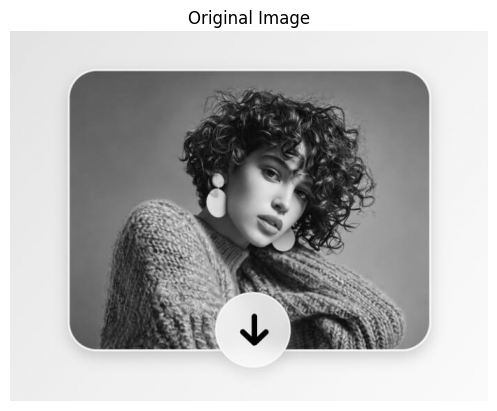

In [13]:
img = cv2.imread('image.jpg',0)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

### PART 1 — Point & Line Detection

(np.float64(-0.5), np.float64(682.5), np.float64(528.5), np.float64(-0.5))

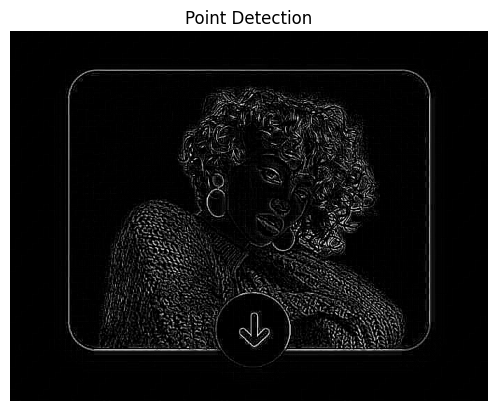

In [14]:
# Point detection mask
kernel = np.array([[-1,-1,-1],
                   [-1, 8,-1],
                   [-1,-1,-1]])

point = cv2.filter2D(img, -1, kernel)

plt.imshow(point, cmap='gray')
plt.title("Point Detection")
plt.axis('off')

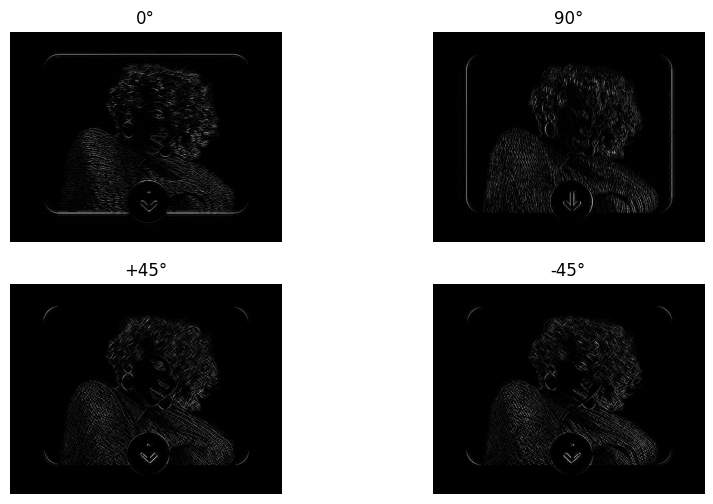

In [15]:
# Masks
horizontal = np.array([[-1,-1,-1],
                       [ 2, 2, 2],
                       [-1,-1,-1]])

vertical = np.array([[-1,2,-1],
                     [-1,2,-1],
                     [-1,2,-1]])

diag45 = np.array([[-1,-1,2],
                   [-1,2,-1],
                   [2,-1,-1]])

diag135 = np.array([[2,-1,-1],
                    [-1,2,-1],
                    [-1,-1,2]])

h = cv2.filter2D(img,-1,horizontal)
v = cv2.filter2D(img,-1,vertical)
d45 = cv2.filter2D(img,-1,diag45)
d135 = cv2.filter2D(img,-1,diag135)

plt.figure(figsize=(10,6))

titles = ["0°","90°","+45°","-45°"]
images = [h,v,d45,d135]

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

### PART 2 — First & Second Derivative

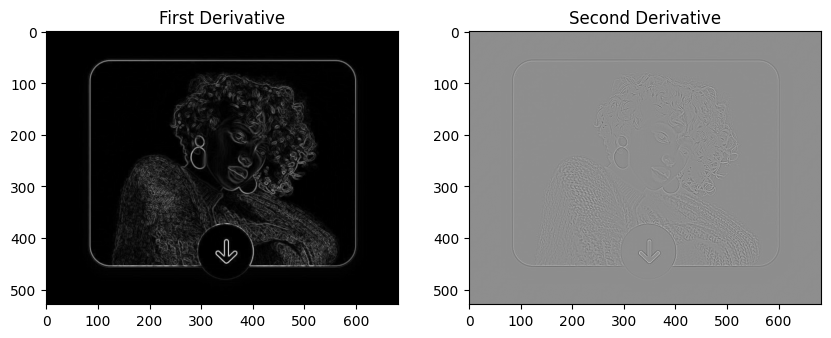

In [16]:
# First derivative (Sobel)
sobelx = cv2.Sobel(img, cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F,0,1,ksize=3)

first = np.sqrt(sobelx**2 + sobely**2)

# Second derivative (Laplacian)
lap = cv2.Laplacian(img, cv2.CV_64F)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(first, cmap='gray')
plt.title("First Derivative")

plt.subplot(122)
plt.imshow(lap, cmap='gray')
plt.title("Second Derivative")

plt.show()

### PART 3 — Edge Detection

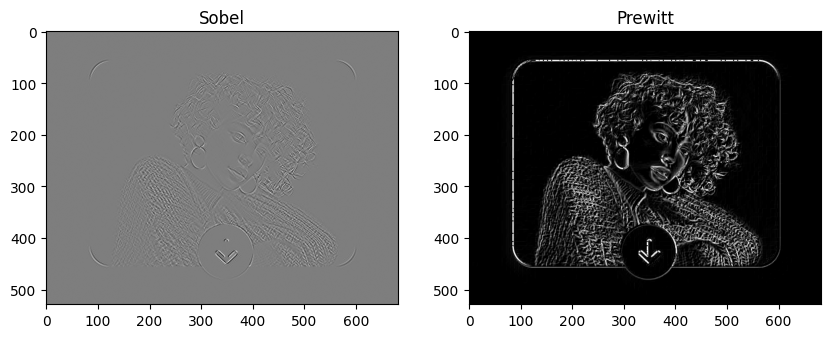

In [17]:
# Sobel
sobel = cv2.Sobel(img, cv2.CV_64F,1,1,ksize=3)

# Prewitt
kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
kernely = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])

prewitt = cv2.filter2D(img,-1,kernelx) + cv2.filter2D(img,-1,kernely)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel")

plt.subplot(122)
plt.imshow(prewitt, cmap='gray')
plt.title("Prewitt")

plt.show()

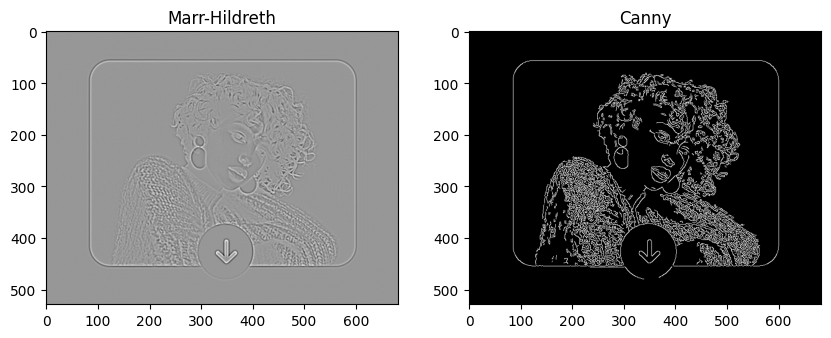

In [18]:
# Marr-Hildreth (LoG)
blur = cv2.GaussianBlur(img,(5,5),0)
log = cv2.Laplacian(blur, cv2.CV_64F)

# Canny
canny = cv2.Canny(img,100,200)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(log, cmap='gray')
plt.title("Marr-Hildreth")

plt.subplot(122)
plt.imshow(canny, cmap='gray')
plt.title("Canny")

plt.show()

### PART 4 — Hough Transform

(np.float64(-0.5), np.float64(682.5), np.float64(528.5), np.float64(-0.5))

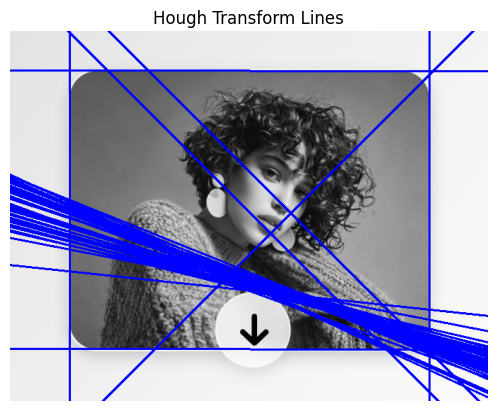

In [19]:
edges = cv2.Canny(img,100,200)

lines = cv2.HoughLines(edges,1,np.pi/180,150)

hough_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

if lines is not None:
    for rho,theta in lines[:,0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a*rho
        y0 = b*rho
        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))

        cv2.line(hough_img,(x1,y1),(x2,y2),(0,0,255),2)

plt.imshow(hough_img)
plt.title("Hough Transform Lines")
plt.axis('off')